In [ ]:
import importlib
import rl4evrp.environment as env_mod

importlib.reload(env_mod)

from rl4evrp.agents import A2CAgent
from rl4evrp.environment import generate_instance


In [27]:
import sys
import csv
import time
from pathlib import Path
from collections import OrderedDict

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt

import rl4evrp as rl
from rl4evrp.utils import run_episode

In [2]:
FULL_STATE_NAME = "Original full"
FULL_STATE_FEATURES = [
    "x",
    "y",
    "demand_normalized",
    "is_charger",
    "is_depot",
    "cargo_capacity_norm",
    "battery_capacity_norm",
    "tw_ready_norm",
    "tw_due_norm",
    "service_time_norm",
]

TEST_STATE_VARIANTS = OrderedDict([
    ("Original full", [
        "x", "y", "demand_normalized", "is_charger", "is_depot",
        "cargo_capacity_norm", "battery_capacity_norm",
        "tw_ready_norm", "tw_due_norm", "service_time_norm",
    ]),
    ("No time features", [
        "x", "y", "demand_normalized", "is_charger", "is_depot",
        "cargo_capacity_norm", "battery_capacity_norm",
        "zeros", "zeros", "zeros",
    ]),
    ("No resource features", [
        "x", "y", "demand_normalized", "is_charger", "is_depot",
        "zeros", "zeros",
        "tw_ready_norm", "tw_due_norm", "service_time_norm",
    ]),
    ("Static graph", [
        "x", "y", "demand_normalized", "is_charger", "is_depot",
        "zeros", "zeros", "zeros", "zeros", "zeros",
    ]),
    ("Constraint-aware alt", [
        "x", "y", "demand_normalized", "is_charger", "is_depot",
        "cargo_capacity_norm", "battery_capacity_norm",
        "tw_window_width_norm", "tw_due_norm", "service_time_norm",
    ]),
])

In [3]:
def attach_state_variant(instances, variant_name, feature_names):
    out = []
    for inst in instances:
        new_inst = dict(inst)
        new_inst["state_variant"] = variant_name
        new_inst["state_feature_names"] = list(feature_names)
        out.append(new_inst)
    return out

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
def train_full_state_model(model_builder, train_instances, eval_instances,
                           n_episodes=2000, device="cpu", save_dir="nb_full_state_model", seed=42):
    set_seed(seed)

    model = model_builder.complete_model()

    train_full = attach_state_variant(train_instances, FULL_STATE_NAME, FULL_STATE_FEATURES)
    eval_full = attach_state_variant(eval_instances, FULL_STATE_NAME, FULL_STATE_FEATURES)

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"Training on full state for {n_episodes} episodes...")
    training_results = train_agent(
        model,
        train_full,
        n_episodes=n_episodes,
        device=device,
        save_dir=save_dir,
        eval_instances=eval_full,
        save_interval=n_episodes,
    )
    return model, training_results

In [5]:
def evaluate_model_on_variant(model, eval_instances, variant_name, feature_names, n_eval=100):
    distances = []
    served_list = []
    feasible_list = []
    charger_list = []

    eval_variant = attach_state_variant(eval_instances, variant_name, feature_names)

    for i in range(min(n_eval, len(eval_variant))):
        inst = dict(eval_variant[i], reward_mode="distance")

        with torch.no_grad():
            _, _, dist, info, _, _, env = run_episode(model, inst, greedy=True)

        distances.append(float(dist))

        n_cust = int((np.array(inst["node_types"]) == 1).sum())
        served = int(info.get("n_customers_served", 0))
        feasible = 1 if served == n_cust else 0
        charger_visits = int(info.get("charger_visits", 0))

        served_list.append(served)
        feasible_list.append(feasible)
        charger_list.append(charger_visits)

    return {
        "distance_mean": float(np.mean(distances)),
        "distance_std": float(np.std(distances)),
        "served_mean": float(np.mean(served_list)),
        "feasible_rate": float(np.mean(feasible_list)),
        "charger_mean": float(np.mean(charger_list)),
    }

In [6]:
def run_full_state_transfer_study_notebook(
    model_builder,
    train_instances,
    eval_instances,
    n_episodes=2000,
    n_eval=50,
    device="cpu",
    output_dir="nb_full_state_transfer_results",
    seed=42,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Train once
    model, _ = train_full_state_model(
        model_builder=model_builder,
        train_instances=train_instances,
        eval_instances=eval_instances,
        n_episodes=n_episodes,
        device=device,
        save_dir=output_dir / "trained_on_full_state",
        seed=seed,
    )

    # Evaluate on altered states
    results = OrderedDict()

    for variant_name, feature_names in TEST_STATE_VARIANTS.items():
        print(f"\nEvaluating full-state model on: {variant_name}")
        t0 = time.time()

        eval_results = evaluate_model_on_variant(
            model=model,
            eval_instances=eval_instances,
            variant_name=variant_name,
            feature_names=feature_names,
            n_eval=n_eval,
        )

        elapsed = time.time() - t0

        eval_results["train_state"] = FULL_STATE_NAME
        eval_results["test_state"] = variant_name
        eval_results["n_features"] = len(feature_names)
        eval_results["n_active_features"] = sum(1 for f in feature_names if f != "zeros")
        eval_results["feature_names"] = str(feature_names)
        eval_results["eval_time_sec"] = elapsed

        results[variant_name] = eval_results

        print(f"Distance: {eval_results['distance_mean']:.3f} ± {eval_results['distance_std']:.3f}")
        print(f"Served:   {eval_results['served_mean']:.2f}")
        print(f"Feasible: {eval_results['feasible_rate']:.0%}")
        print(f"Chargers: {eval_results['charger_mean']:.2f}")

    # Save CSV
    csv_path = output_dir / "full_state_transfer_results.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(list(results.values())[0].keys()))
        writer.writeheader()
        for r in results.values():
            writer.writerow(r)

    print(f"\nSaved CSV to: {csv_path}")

    return model, results

In [7]:
def plot_transfer_results(results):
    configs = list(results.keys())
    distances = [results[c]["distance_mean"] for c in configs]
    dist_stds = [results[c]["distance_std"] for c in configs]
    feasibility = [results[c]["feasible_rate"] * 100 for c in configs]
    served = [results[c]["served_mean"] for c in configs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(configs))

    baseline = distances[0]
    colors = []
    for i, d in enumerate(distances):
        if i == 0:
            colors.append("#27ae60")
        elif d > baseline * 1.15:
            colors.append("#c0392b")
        elif d > baseline * 1.05:
            colors.append("#f39c12")
        else:
            colors.append("#3498db")

    bars1 = ax1.bar(x, distances, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5, width=0.65)
    ax1.errorbar(x, distances, yerr=dist_stds, fmt="none", ecolor="#2c3e50", capsize=3, capthick=1, linewidth=1)
    ax1.axhline(baseline, color="#27ae60", ls="--", lw=1, alpha=0.5)

    ax1.set_xticks(x)
    ax1.set_xticklabels(configs, rotation=30, ha="right", fontsize=9)
    ax1.set_ylabel("Average distance")
    ax1.set_title("(a) Full-state policy tested on altered states", loc="left", fontweight="bold")
    ax1.grid(axis="y", alpha=0.15)

    width = 0.35
    ax2.bar(x - width/2, served, width, alpha=0.85, label="Customers served", edgecolor="white")
    ax2.bar(x + width/2, feasibility, width, alpha=0.85, label="Feasibility (%)", edgecolor="white")

    ax2.set_xticks(x)
    ax2.set_xticklabels(configs, rotation=30, ha="right", fontsize=9)
    ax2.set_ylabel("Value")
    ax2.set_title("(b) Sensitivity of service and feasibility", loc="left", fontweight="bold")
    ax2.legend(fontsize=9, loc="lower left", framealpha=0.9)
    ax2.grid(axis="y", alpha=0.15)

    plt.tight_layout()
    plt.show()

In [8]:
set_seed(42)

framework = rl.RL4EVRP()
problem_config = framework.read_yaml("problem")
model_config = framework.read_yaml("model")
env_config = framework.read_yaml("env")

model_builder = framework.build()
model = model_builder.complete_model()

print("Model expects input dim:", model.encoder.embed.weight.shape[1])
print("Decoder ctx dim:", model.decoder.proj_ctx.weight.shape[1])

instance_cfg = problem_config["instance_generation"]
n_train = 500   # small test first
n_eval = 50

seed_offset = instance_cfg.get("seed_offset", 0)

train_instances = [
    framework.generate_instance(seed=seed_offset + i)
    for i in range(n_train)
]

eval_instances = [
    framework.generate_instance(seed=1000 + seed_offset + i)
    for i in range(n_eval)
]

trained_model, results = run_full_state_transfer_study_notebook(
    model_builder=model_builder,
    train_instances=train_instances,
    eval_instances=eval_instances,
    n_episodes=500,   # small test first
    n_eval=50,
    device=str(framework.device),
    output_dir="nb_full_state_transfer_results",
    seed=42,
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_in

✓ Device: cpu
✓ Output directory: results_xai
✓ Agent initialized with 488065 parameters
Model expects input dim: 10
Decoder ctx dim: 131
✓ Agent initialized with 488065 parameters
Training on full state for 500 episodes...


KeyboardInterrupt: 

In [ ]:
plot_transfer_results(results)

## test

In [30]:
LEGACY_7_FEATURES = [
    "x",
    "y",
    "demand_normalized",
    "is_charger",
    "is_depot",
    "cargo_capacity_norm",
    "battery_capacity_norm",
]

TEST_STATE_VARIANTS_7 = OrderedDict([
    ("Original full 7", [
        "x",
        "y",
        "demand_normalized",
        "is_charger",
        "is_depot",
        "cargo_capacity_norm",
        "battery_capacity_norm",
    ]),
    ("No battery", [
        "x",
        "y",
        "demand_normalized",
        "is_charger",
        "is_depot",
        "cargo_capacity_norm",
        "zeros",
    ]),
    ("No cargo", [
        "x",
        "y",
        "demand_normalized",
        "is_charger",
        "is_depot",
        "zeros",
        "battery_capacity_norm",
    ]),
    ("No node type flags", [
        "x",
        "y",
        "demand_normalized",
        "zeros",
        "zeros",
        "cargo_capacity_norm",
        "battery_capacity_norm",
    ]),
    ("Spatial+demand only", [
        "x",
        "y",
        "demand_normalized",
        "zeros",
        "zeros",
        "zeros",
        "zeros",
    ]),

    ("Time-window focused", [
    "x",
    "y",
    "demand_normalized",
    "is_charger",
    "is_depot",
    "tw_ready_norm",
    "tw_due_norm",
    "service_time_norm",
    "zeros",
    "zeros",
    ])
])

In [15]:
def attach_state_variant(instances, variant_name, feature_names):
    out = []
    for inst in instances:
        new_inst = dict(inst)
        new_inst["state_variant"] = variant_name
        new_inst["state_feature_names"] = list(feature_names)
        out.append(new_inst)
    return out


def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [16]:
def load_legacy_checkpoint(model_path, device="cpu"):
    """
    Load old RL4EVRP checkpoints with:
      - encoder input dim = 7
      - decoder context dim = 130
      - no time context in decoder
    """
    state_dict = torch.load(model_path, map_location=device)

    in_dim = state_dict["encoder.embed.weight"].shape[1]
    ctx_dim = state_dict["decoder.proj_ctx.weight"].shape[1]

    print(f"\nLoading checkpoint: {model_path}")
    print("Checkpoint signature:")
    print(f"  encoder input dim = {in_dim}")
    print(f"  decoder ctx dim   = {ctx_dim}")

    if in_dim != 7 or ctx_dim != 130:
        raise ValueError(
            f"Checkpoint {model_path} is not the expected legacy 7-feature format. "
            f"Got input_dim={in_dim}, ctx_dim={ctx_dim}"
        )

    framework = rl.RL4EVRP()

    model = A2CAgent(
        input_dim=7,
        embed_dim=128,
        n_heads=8,
        n_layers=3,
        enc_type="gat",
        device=device,
        use_time_context=False,
    )

    print("Current model signature:")
    print(f"  encoder.embed.weight = {tuple(model.encoder.embed.weight.shape)}")
    print(f"  decoder.proj_ctx.weight = {tuple(model.decoder.proj_ctx.weight.shape)}")

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return framework, model, LEGACY_7_FEATURES

In [17]:
def evaluate_model_on_variant(model, eval_instances, variant_name, feature_names, n_eval=100):
    distances = []
    served_list = []
    feasible_list = []
    charger_list = []

    eval_variant = attach_state_variant(eval_instances, variant_name, feature_names)

    for i in range(min(n_eval, len(eval_variant))):
        inst = dict(eval_variant[i], reward_mode="distance")

        with torch.no_grad():
            _, _, dist, info, _, _, env = run_episode(
                model,
                inst,
                greedy=True
            )

        distances.append(float(dist))

        n_cust = int((np.array(inst["node_types"]) == 1).sum())
        served = int(info.get("n_customers_served", 0))
        feasible = 1 if served == n_cust else 0
        charger_visits = int(info.get("charger_visits", 0))

        served_list.append(served)
        feasible_list.append(feasible)
        charger_list.append(charger_visits)

    return {
        "distance_mean": float(np.mean(distances)),
        "distance_std": float(np.std(distances)),
        "served_mean": float(np.mean(served_list)),
        "feasible_rate": float(np.mean(feasible_list)),
        "charger_mean": float(np.mean(charger_list)),
    }

In [18]:
def evaluate_checkpoint_across_states(
    checkpoint_name,
    model,
    eval_instances,
    test_variants,
    n_eval=100,
):
    results = OrderedDict()

    for variant_name, feature_names in test_variants.items():
        print(f"\nEvaluating {checkpoint_name} on: {variant_name}")

        eval_results = evaluate_model_on_variant(
            model=model,
            eval_instances=eval_instances,
            variant_name=variant_name,
            feature_names=feature_names,
            n_eval=n_eval,
        )

        eval_results["checkpoint"] = checkpoint_name
        eval_results["test_state"] = variant_name
        eval_results["n_features"] = len(feature_names)
        eval_results["n_active_features"] = sum(1 for f in feature_names if f != "zeros")
        eval_results["feature_names"] = str(feature_names)

        results[variant_name] = eval_results

        print(f"Distance: {eval_results['distance_mean']:.3f} ± {eval_results['distance_std']:.3f}")
        print(f"Served:   {eval_results['served_mean']:.2f}")
        print(f"Feasible: {eval_results['feasible_rate']:.0%}")
        print(f"Chargers: {eval_results['charger_mean']:.2f}")

    return results

In [34]:
def plot_checkpoint_results(results, title="Checkpoint sensitivity study", save_path=None):
    configs = list(results.keys())
    distances = [results[c]["distance_mean"] for c in configs]
    dist_stds = [results[c]["distance_std"] for c in configs]
    feasibility = [results[c]["feasible_rate"] * 100 for c in configs]
    served = [results[c]["served_mean"] for c in configs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.8))
    x = np.arange(len(configs))

    baseline = distances[0]
    colors = []
    for i, d in enumerate(distances):
        if i == 0:
            colors.append("#27ae60")
        elif d > baseline * 1.15:
            colors.append("#c0392b")
        elif d > baseline * 1.05:
            colors.append("#f39c12")
        else:
            colors.append("#3498db")

    # Panel A
    bars1 = ax1.bar(
        x, distances,
        color=colors,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
        width=0.65
    )
    ax1.errorbar(
        x, distances,
        yerr=dist_stds,
        fmt="none",
        ecolor="#2c3e50",
        capsize=3,
        capthick=1,
        linewidth=1
    )
    ax1.axhline(baseline, color="#27ae60", ls="--", lw=1, alpha=0.5)

    ax1.set_xticks(x)
    ax1.set_xticklabels(configs, rotation=30, ha="right", fontsize=9)
    ax1.set_ylabel("Average distance")
    ax1.grid(axis="y", alpha=0.15)

    # Title below plot A
    ax1.text(
        0.5, -0.28,
        "(a) Distance sensitivity",
        transform=ax1.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

    # Panel B
    width = 0.35
    ax2.bar(
        x - width/2, served, width,
        alpha=0.85,
        label="Customers served",
        edgecolor="white"
    )
    ax2.bar(
        x + width/2, feasibility, width,
        alpha=0.85,
        label="Feasibility (%)",
        edgecolor="white"
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(configs, rotation=30, ha="right", fontsize=9)
    ax2.set_ylabel("Value")
    ax2.grid(axis="y", alpha=0.15)

    # Title below plot B
    ax2.text(
        0.5, -0.28,
        "(b) Service and feasibility",
        transform=ax2.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

    # Legend moved to top right
    ax2.legend(fontsize=9, loc="upper right", framealpha=0.9)

    fig.suptitle(title, fontsize=12, fontweight="bold")

    # Add more bottom space for below-axis titles
    plt.subplots_adjust(bottom=0.28, top=0.88, wspace=0.25)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    return fig

In [20]:
def results_to_dataframe(*results_dicts):
    rows = []
    for results in results_dicts:
        for _, r in results.items():
            rows.append(r)
    return pd.DataFrame(rows)

In [32]:
set_seed(42)

n_eval = 50

eval_instances = [
    generate_instance(
        n_customers=15,
        seed=1000 + i,
        charger_prob=0.15,
        cargo_cap=30.0,
        battery_cap=100.0,
        tw_enabled=True,
    )
    for i in range(n_eval)
]

framework_evrp, model_evrp, feature_names_evrp = load_legacy_checkpoint(
    "agent_episode_100000.pt",
    device="cpu"   # or str(torch.device("cuda")) if you want
)

framework_evrptw, model_evrptw, feature_names_evrptw = load_legacy_checkpoint(
    "agent_evrptw_60k.pt",
    device="cpu"
)


Loading checkpoint: agent_episode_100000.pt
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
✓ Device: cpu
✓ Output directory: results_xai
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)

Loading checkpoint: agent_evrptw_60k.pt
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
✓ Device: cpu
✓ Output directory: results_xai
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)


In [36]:
results_evrp = evaluate_checkpoint_across_states(
    checkpoint_name="agent_episode_150420.pt",
    model=model_evrp,
    eval_instances=eval_instances,
    test_variants=TEST_STATE_VARIANTS_7,
    n_eval=n_eval,
)

results_evrptw = evaluate_checkpoint_across_states(
    checkpoint_name="agent_evrptw_60k.pt",
    model=model_evrptw,
    eval_instances=eval_instances,
    test_variants=TEST_STATE_VARIANTS_7,
    n_eval=n_eval,
)


Evaluating agent_episode_150420.pt on: Original full 7
Distance: 2.625 ± 0.561
Served:   3.86
Feasible: 0%
Chargers: 0.90

Evaluating agent_episode_150420.pt on: No battery
Distance: 2.673 ± 0.668
Served:   3.82
Feasible: 0%
Chargers: 0.90

Evaluating agent_episode_150420.pt on: No cargo
Distance: 2.582 ± 0.554
Served:   3.82
Feasible: 0%
Chargers: 0.82

Evaluating agent_episode_150420.pt on: No node type flags
Distance: 2.851 ± 0.679
Served:   2.60
Feasible: 0%
Chargers: 3.38

Evaluating agent_episode_150420.pt on: Spatial+demand only
Distance: 2.881 ± 0.732
Served:   2.62
Feasible: 0%
Chargers: 3.56

Evaluating agent_episode_150420.pt on: Time-window focused


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x10 and 7x128)

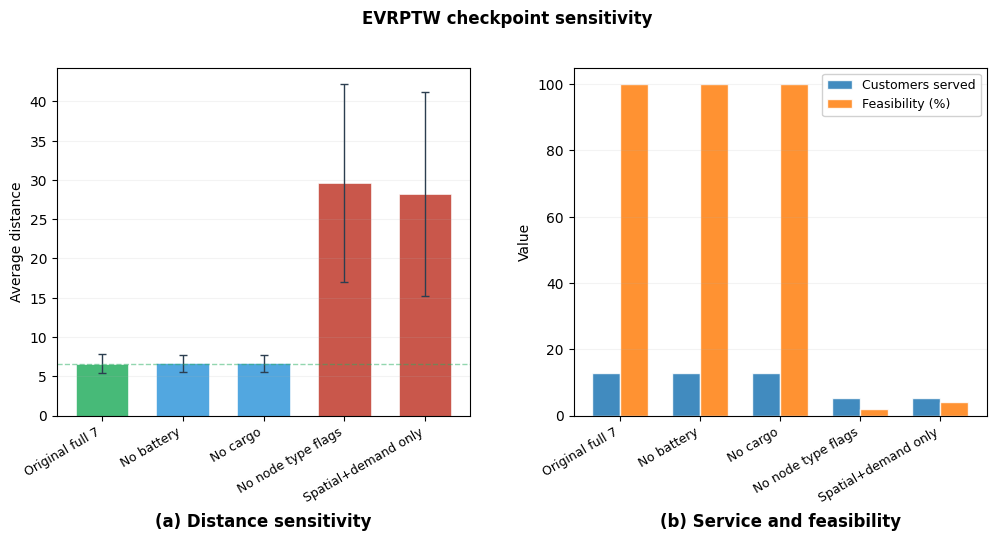

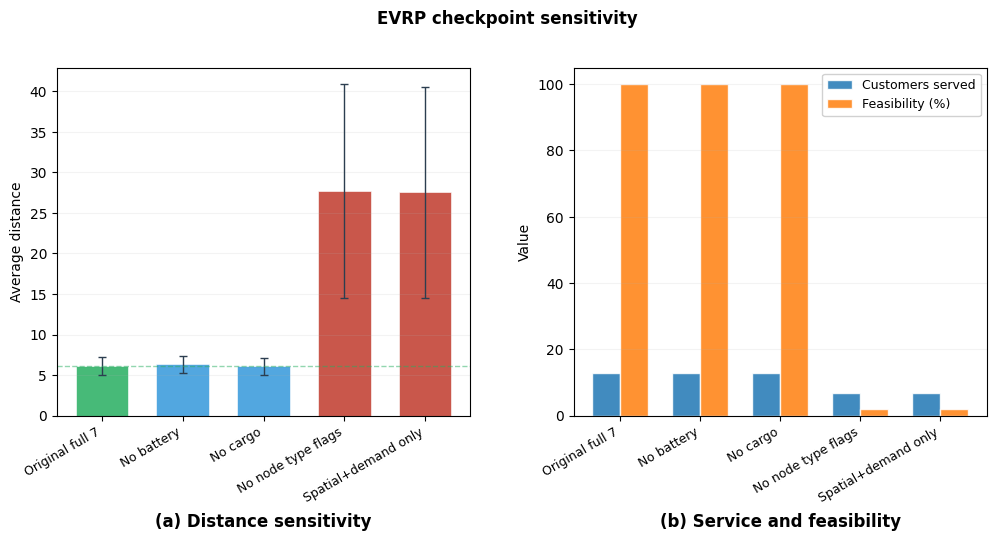

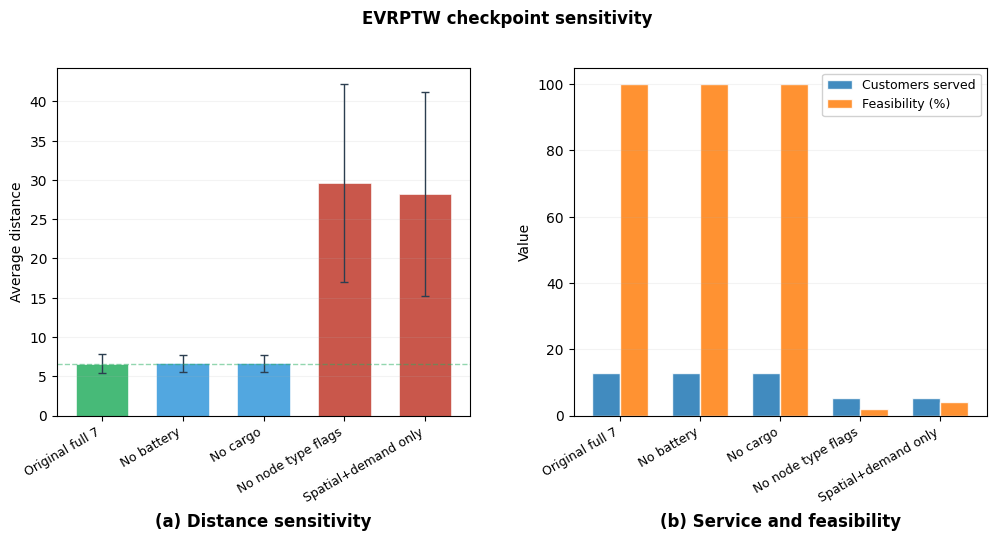

In [35]:
plot_checkpoint_results(results_evrp, title="EVRP checkpoint sensitivity")
plot_checkpoint_results(results_evrptw, title="EVRPTW checkpoint sensitivity")

In [26]:
df_results.to_csv("checkpoint_state_sensitivity_results.csv", index=False)
print("Saved to checkpoint_state_sensitivity_results.csv")

Saved to checkpoint_state_sensitivity_results.csv


In [25]:
df_results = results_to_dataframe(results_evrp, results_evrptw)
df_results

,distance_mean,distance_std,served_mean,feasible_rate,charger_mean,checkpoint,test_state,n_features,n_active_features,feature_names
0,6.136346,1.085092,12.72,1.00,0.00,agent_episode_100000.pt,Original full 7,7,7,"['x', 'y', 'demand_normalized', 'is_charger', ..."
1,6.329361,1.049213,12.72,1.00,0.00,agent_episode_100000.pt,No battery,7,6,"['x', 'y', 'demand_normalized', 'is_charger', ..."
2,6.095010,1.036963,12.72,1.00,0.00,agent_episode_100000.pt,No cargo,7,6,"['x', 'y', 'demand_normalized', 'is_charger', ..."
3,27.719765,13.176753,6.72,0.02,37.72,agent_episode_100000.pt,No node type flags,7,5,"['x', 'y', 'demand_normalized', 'zeros', 'zero..."
4,27.559052,13.024026,6.68,0.02,37.78,agent_episode_100000.pt,Spatial+demand only,7,3,"['x', 'y', 'demand_normalized', 'zeros', 'zero..."
5,6.611395,1.172021,12.72,1.00,0.00,agent_evrptw_60k.pt,Original full 7,7,7,"['x', 'y', 'demand_normalized', 'is_charger', ..."
6,6.631639,1.069653,12.72,1.00,0.00,agent_evrptw_60k.pt,No battery,7,6,"['x', 'y', 'demand_normalized', 'is_charger', ..."
7,6.631359,1.099683,12.72,1.00,0.00,agent_evrptw_60k.pt,No cargo,7,6,"['x', 'y', 'demand_normalized', 'is_charger', ..."
8,29.623496,12.569932,5.22,0.02,34.68,agent_evrptw_60k.pt,No node type flags,7,5,"['x', 'y', 'demand_normalized', 'zeros', 'zero..."
9,28.186911,12.990569,5.26,0.04,36.86,agent_evrptw_60k.pt,Spatial+demand only,7,3,"['x', 'y', 'demand_normalized', 'zeros', 'zero..."
